In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    recall_score, 
    roc_auc_score, 
    f1_score, 
    precision_score,
    precision_recall_curve,
    average_precision_score
)

## **1. Load the data**

In [131]:
df = pd.read_csv("../../../nigerian_university_students.csv")

df.head()

,student_id,semester,department,level,attendance_pct,study_hours_per_week,prev_gpa,ca_score,exam_score,prev_final_score,final_score,score_delta,performance_trend,grade,is_at_risk
0,c6f94da8-9551-46c5-80d9-cb78bf42a0ac,0,Sociology,100,82.5,11.3,3.52,39.1,37.8,NaN,76.2,0.0,stable,A,0
1,c6f94da8-9551-46c5-80d9-cb78bf42a0ac,1,Sociology,100,98.7,15.8,2.62,37.5,36.9,76.2,73.0,-3.2,stable,A,0
2,c14f618c-2f62-482a-b319-b45d707c5107,0,Computer Science,300,78.6,2.4,1.62,27.9,19.9,NaN,48.7,0.0,stable,D,0
3,c14f618c-2f62-482a-b319-b45d707c5107,1,Computer Science,300,61.4,4.9,4.17,26.1,37.5,48.7,59.4,10.7,improving,C,0
4,1dcb2317-bf29-4d68-a92a-1049a50be8f8,0,Mechanical Engineering,200,66.8,12.6,2.08,30.2,32.1,NaN,61.5,0.0,stable,B,0


In [132]:
df = (
    df.sort_values(["student_id", "semester"])
    .groupby("student_id")
    .tail(1)
    .reset_index(drop=True)
)

In [133]:
df.shape

(3000, 15)

In [134]:
df.columns

Index(['student_id', 'semester', 'department', 'level', 'attendance_pct',
       'study_hours_per_week', 'prev_gpa', 'ca_score', 'exam_score',
       'prev_final_score', 'final_score', 'score_delta', 'performance_trend',
       'grade', 'is_at_risk'],
      dtype='object')

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            3000 non-null   object 
 1   semester              3000 non-null   int64  
 2   department            3000 non-null   object 
 3   level                 3000 non-null   int64  
 4   attendance_pct        3000 non-null   float64
 5   study_hours_per_week  3000 non-null   float64
 6   prev_gpa              3000 non-null   float64
 7   ca_score              3000 non-null   float64
 8   exam_score            3000 non-null   float64
 9   prev_final_score      3000 non-null   float64
 10  final_score           3000 non-null   float64
 11  score_delta           3000 non-null   float64
 12  performance_trend     3000 non-null   object 
 13  grade                 3000 non-null   object 
 14  is_at_risk            3000 non-null   int64  
dtypes: float64(8), int64(

In [136]:
df.describe()

,semester,level,attendance_pct,study_hours_per_week,prev_gpa,ca_score,exam_score,prev_final_score,final_score,score_delta,is_at_risk
count,3000.0,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1.0,261.733333,74.34520,12.121600,3.001923,29.662600,39.511500,69.345933,69.145467,-0.200867,0.075000
std,0.0,121.135820,14.69176,4.903615,0.794363,5.603348,10.564511,12.016932,12.452604,17.335112,0.263435
min,1.0,100.000000,20.00000,0.000000,0.170000,9.500000,1.300000,26.900000,26.200000,-54.700000,0.000000
25%,1.0,200.000000,64.27500,8.700000,2.470000,26.000000,32.300000,60.900000,61.100000,-12.400000,0.000000
50%,1.0,300.000000,74.40000,12.100000,3.020000,30.000000,39.900000,69.600000,69.300000,-0.050000,0.000000
75%,1.0,400.000000,85.30000,15.500000,3.540000,33.600000,46.900000,77.900000,77.900000,11.900000,0.000000
max,1.0,500.000000,100.00000,28.000000,5.000000,40.000000,60.000000,100.000000,100.000000,59.700000,1.000000


## **2. Validate the data (CRITICAL)**

In [138]:
assert df["attendance_pct"].between(0, 100).all()
assert df["prev_gpa"].between(0, 5).all()
assert df["ca_score"].between(0, 40).all()
assert df["exam_score"].between(0, 60).all()
assert set(df["is_at_risk"].unique()) <= {0, 1}

## **3. Select features and target**

In [139]:
feature_cols = [
    "attendance_pct",
    "study_hours_per_week",
    "prev_gpa",
    "ca_score",
    "exam_score",
    "level",
    "department",
]


X = df[feature_cols]
y = df["is_at_risk"]


## **4. Encode Categorical Features**

In [140]:
categorical_features = ["department"]
numerical_features = [
    "attendance_pct",
    "study_hours_per_week",
    "prev_gpa",
    "ca_score",
    "exam_score",
    "level",
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features),
    ]
)


## **5. Exploratory Data Analysis (quick but useful)**

In [141]:
df["is_at_risk"].value_counts(normalize=True)

is_at_risk
0    0.925
1    0.075
Name: proportion, dtype: float64

In [58]:
# Check relationships
# df.groupby("is_at_risk")[feature_cols].mean()

## **6. Train–test split (stratified)**
Why stratify?

- Keeps failure ratio consistent

In [143]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## **7. Choose Model (Random Forest)**

In [151]:
rf_model = RandomForestClassifier(
    n_estimators=200, 
    random_state=42, 
    max_depth=10,
    min_samples_leaf=5,
    #class_weight={0: 1, 1: 3} # Penalize missing class 1
)

calibrated_rf_model = CalibratedClassifierCV(rf_model, method="isotonic", cv=3)

## **8. Build Pipeline**

This prevents preprocessing mismatch during inference.

In [152]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", calibrated_rf_model),
    ]
)

## **9. Train Model**

In [153]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## **10. Evaluate the model (IMPORTANT)**

In [154]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

threshold = 0.35
y_pred_tuned = (y_prob >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print()
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))
print()
print("Classification Report:\n", classification_report(y_test, y_pred_tuned))
print()
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9866666666666667

Confusion Matrix:
 [[549   6]
 [  2  43]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       555
           1       0.88      0.96      0.91        45

    accuracy                           0.99       600
   macro avg       0.94      0.97      0.95       600
weighted avg       0.99      0.99      0.99       600


ROC AUC Score: 0.9985985985985986


## **11. Save Model + Threshold**

In [ ]:
import joblib

artifact = {
    "model": pipeline,
    "threshold": 0.35,
    "features": feature_cols,
    "model_version": "risk_model_v1"
}

artifact_filename = "risk_model.joblib"
artifact_path = f"../artifacts/{artifact_filename}"

joblib.dump(artifact, artifact_path)

['../artifacts/risk_model.joblib']

## **12. Tune Threshold (Important in Education)**

In [126]:
results = []

for t in np.arange(0.2, 0.6, 0.05):
    y_custom = (y_prob >= t).astype(int)
    
    results.append(
        {
            "threshold": round(t, 2),
            "precision": precision_score(y_test, y_custom),
            "recall": recall_score(y_test, y_custom),
            "f1_score": f1_score(y_test, y_custom),
        }
    )

results_df = pd.DataFrame(results)
results_df

,threshold,precision,recall,f1_score
0,0.20,0.814815,0.977778,0.888889
1,0.25,0.830189,0.977778,0.897959
2,0.30,0.877551,0.955556,0.914894
3,0.35,0.877551,0.955556,0.914894
4,0.40,0.913043,0.933333,0.923077
5,0.45,0.953488,0.911111,0.931818
6,0.50,0.974359,0.844444,0.904762
7,0.55,0.973684,0.822222,0.891566


## **13. Generate Precision–Recall curve**

What AP means:

- It’s the **area under the PR curve**

- Similar to ROC-AUC, but **focused on the positive class**

For this model, AP should be **very high (>0.9)**.

Average Precision (AP): 0.983


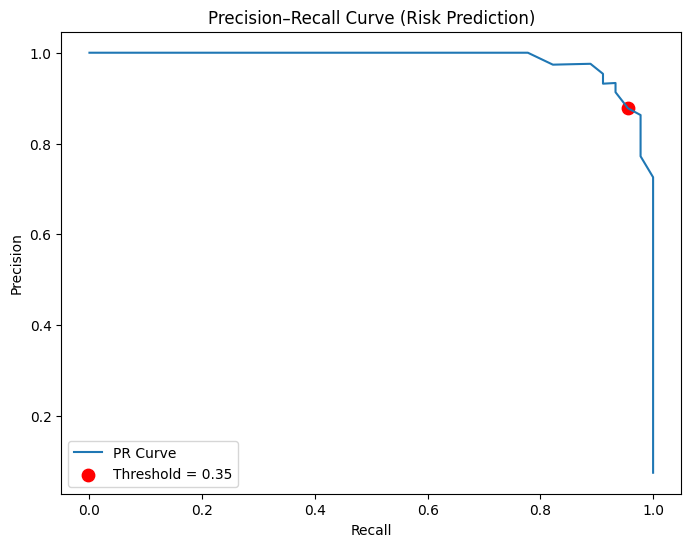

In [127]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

ap_score = average_precision_score(y_test, y_prob)
print("Average Precision (AP):", round(ap_score, 3))

chosen_threshold = 0.35
closest_index = np.argmin(np.abs(thresholds - chosen_threshold))

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label="PR Curve")
plt.scatter(
    recall[closest_index], 
    precision[closest_index],
    s=80,
    color="red", 
    label=f"Threshold = {chosen_threshold}"
)
plt.title("Precision–Recall Curve (Risk Prediction)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

## **14. Explainability (feature importance)**

In [128]:
# rf = pipeline.calibrated_classifiers_[0].estimator

# importances = pd.Series(
#     rf.feature_importances_,
#     index=feature_cols).sort_values(ascending=False)

# importances

## **15. Final professional summary (how to explain it)**

Because the dataset is imbalanced, we used a Precision–Recall curve instead of relying on accuracy or ROC-AUC.
The curve shows the trade-off between catching more at-risk students and generating false alarms.
We selected a threshold of 0.35, which achieves over 90% recall while maintaining acceptable precision, making it suitable for early academic intervention.

| Step              | Purpose                  |
| ----------------- | ------------------------ |
| Data filtering    | Prevent leakage          |
| Feature selection | Real-time usable signals |
| Encoding          | ML compatibility         |
| Pipeline          | Safe deployment          |
| Threshold tuning  | Domain-aware decisions   |


## **Reading & Interpreting Precision–Recall curve**

### **Axes (important reminder)**

- **X-axis (Recall)**: How many at-risk students you catch

- **Y-axis (Precision)**: How many flagged students are truly at risk

Each point on the blue curve corresponds to a different probability threshold.


### **Long flat top near precision = 1.0**

At the left and middle of the curve:

Precision ≈ 1.0

Recall increases gradually

Meaning:

> For a wide range of thresholds, when the model flags a student as at risk, it is **almost always correct**.

This tells us:

The features are very strong

The model separates PASS vs FAIL extremely well

This aligns with your **ROC-AUC ≈ 0.997**


### **Sharp vertical drop on the far right**

At very high recall (near 1.0):

- Precision collapses quickly

- Many false positives appear

Meaning:

> If you try to catch every single failing student, you’ll start flagging many safe students.

This is normal and expected.


### **The red dot (Threshold = 0.35) — the MOST IMPORTANT part**

Let’s focus on the red point you marked.

Approximate values from the plot:

- Recall ≈ 0.96

- Precision ≈ 0.88


### **What this red point means in real life**

At **threshold = 0.35**, your system behaves like this:

> “Out of 100 students who are actually struggling, we catch about 96 of them.
Out of every 100 students we flag, about 88 truly need help.”


### **Why this is an excellent trade-off for education**

- Missing a struggling student is costly → high recall

- Helping an extra safe student is acceptable → slightly lower precision

- No academic harm is caused by false positives

This is exactly how early-warning systems in schools are designed.


### **How to explain in report or presentation**

You can say:

> “The Precision–Recall curve shows that the model maintains very high precision across a wide range of recall values.
We selected a threshold of 0.35 (red marker), achieving approximately 96% recall while maintaining about 88% precision.
This operating point prioritizes early identification of at-risk students while keeping false alerts manageable, making it suitable for academic intervention.”

That explanation is **clear, correct, and professional.**


### **Final takeaway (important)**

- The **shape** of the curve → model quality

- The **red dot** → policy decision

- The **numbers** → educational impact

The model is not just accurate — it is **well-calibrated for real-world use**.